# Analisis Sentimen Ulasan Produk Amazon India

Proyek ini dibuat untuk menganalisis apa yang sebenarnya pelanggan rasakan dari ulasan yang mereka tulis di Amazon. Bukan cuma lihat rating bintangnya — tapi baca teksnya, dan cari tahu: kategori produk mana yang banyak dikeluhkan, apakah diskon besar bikin orang lebih kecewa, dan kata-kata apa yang paling sering muncul di ulasan negatif.

Dataset yang dipakai adalah Amazon Sales Dataset dengan 1.465 produk. Setelah diproses, datanya menghasilkan sekitar 11.700 ulasan individual yang siap dianalisis.

---

**Alur kerja notebook ini:**

1. Load data dan lihat kondisinya
2. Bersihkan dan rapikan struktur data
3. Preprocessing teks ulasan
4. Analisis sentimen pakai VADER
5. Visualisasi hasil
6. Kesimpulan dan insight

## 1. Import Library

Pertama-tama install dulu semua library yang dibutuhkan. Kalau sudah pernah install sebelumnya, cell ini bisa di-skip.

In [4]:
# !pip install pandas numpy matplotlib seaborn plotly wordcloud vaderSentiment nltk

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import plotly.express as px
import re
import warnings
warnings.filterwarnings('ignore')
!pip install vaderSentiment

import nltk
from nltk.corpus import stopwords
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from wordcloud import WordCloud
from collections import Counter

# download data pendukung nltk
nltk.download('stopwords', quiet=True)
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)

# pengaturan tampilan grafik
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 12
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
sns.set_palette('muted')

# warna konsisten untuk setiap label sentimen
WARNA = {
    'positive': '#1D9E75',
    'neutral' : '#EF9F27',
    'negative': '#E24B4A'
}

print('library siap dipakai')

library siap dipakai


## 2. Load Data

Sebelum ngapa-ngapain, lihat dulu datanya — berapa baris, kolom apa saja, ada yang kosong nggak, dan ada duplikat nggak. Ini langkah pertama yang wajib dilakukan setiap kali dapat dataset baru.

In [6]:
# load data mentah, simpan di df_raw supaya bisa balik ke sini kalau ada yang salah
df_raw = pd.read_csv('amazon.csv')

print(f'total baris  : {df_raw.shape[0]:,}')
print(f'total kolom  : {df_raw.shape[1]}')
print(f'nama kolom   : {list(df_raw.columns)}')

total baris  : 1,465
total kolom  : 16
nama kolom   : ['product_id', 'product_name', 'category', 'discounted_price', 'actual_price', 'discount_percentage', 'rating', 'rating_count', 'about_product', 'user_id', 'user_name', 'review_id', 'review_title', 'review_content', 'img_link', 'product_link']


In [7]:
# lihat 3 baris pertama untuk memahami isi datanya
df_raw.head(3)

,product_id,product_name,category,discounted_price,actual_price,discount_percentage,rating,rating_count,about_product,user_id,user_name,review_id,review_title,review_content,img_link,product_link
0,B07JW9H4J1,Wayona Nylon Braided USB to Lightning Fast Cha...,Computers&Accessories|Accessories&Peripherals|...,₹399,"₹1,099",64%,4.2,"24,269",High Compatibility : Compatible With iPhone 12...,"AG3D6O4STAQKAY2UVGEUV46KN35Q,AHMY5CWJMMK5BJRBB...","Manav,Adarsh gupta,Sundeep,S.Sayeed Ahmed,jasp...","R3HXWT0LRP0NMF,R2AJM3LFTLZHFO,R6AQJGUP6P86,R1K...","Satisfied,Charging is really fast,Value for mo...",Looks durable Charging is fine tooNo complains...,https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Wayona-Braided-WN3LG1-Sy...
1,B098NS6PVG,Ambrane Unbreakable 60W / 3A Fast Charging 1.5...,Computers&Accessories|Accessories&Peripherals|...,₹199,₹349,43%,4.0,"43,994","Compatible with all Type C enabled devices, be...","AECPFYFQVRUWC3KGNLJIOREFP5LQ,AGYYVPDD7YG7FYNBX...","ArdKn,Nirbhay kumar,Sagar Viswanathan,Asp,Plac...","RGIQEG07R9HS2,R1SMWZQ86XIN8U,R2J3Y1WL29GWDE,RY...","A Good Braided Cable for Your Type C Device,Go...",I ordered this cable to connect my phone to An...,https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Ambrane-Unbreakable-Char...
2,B096MSW6CT,Sounce Fast Phone Charging Cable & Data Sync U...,Computers&Accessories|Accessories&Peripherals|...,₹199,"₹1,899",90%,3.9,"7,928",【 Fast Charger& Data Sync】-With built-in safet...,"AGU3BBQ2V2DDAMOAKGFAWDDQ6QHA,AESFLDV2PT363T2AQ...","Kunal,Himanshu,viswanath,sai niharka,saqib mal...","R3J3EQQ9TZI5ZJ,R3E7WBGK7ID0KV,RWU79XKQ6I1QF,R2...","Good speed for earlier versions,Good Product,W...","Not quite durable and sturdy,https://m.media-a...",https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Sounce-iPhone-Charging-C...


In [8]:
# cek tipe data tiap kolom
# kolom harga masih object (string) karena ada simbol ₹ — nanti kita bersihkan
print(df_raw.dtypes)

product_id             object
product_name           object
category               object
discounted_price       object
actual_price           object
discount_percentage    object
rating                 object
rating_count           object
about_product          object
user_id                object
user_name              object
review_id              object
review_title           object
review_content         object
img_link               object
product_link           object
dtype: object


In [9]:
# cek missing values — pakai isnull().sum() biar langsung dapat angkanya per kolom
missing = df_raw.isnull().sum()
missing_pct = (missing / len(df_raw) * 100).round(2)

ringkasan_missing = pd.DataFrame({
    'jumlah missing' : missing,
    'persen (%)': missing_pct
})

# tampilkan hanya kolom yang punya missing values
print(ringkasan_missing[ringkasan_missing['jumlah missing'] > 0])
print(f'\ntotal missing: {missing.sum()} sel')

              jumlah missing  persen (%)
rating_count               2        0.14

total missing: 2 sel


In [10]:
# cek duplikat berdasarkan product_id
print(f'jumlah duplikat: {df_raw.duplicated(subset="product_id").sum()}')

# ini yang menarik — setiap baris punya BANYAK ulasan yang digabung pakai koma
# jadi 1 baris bukan 1 ulasan, melainkan sekitar 8 ulasan sekaligus
n_ulasan_per_baris = df_raw['review_content'].str.split(',').str.len()
print(f'\nrata-rata ulasan per baris   : {n_ulasan_per_baris.mean():.1f}')
print(f'estimasi total ulasan        : {n_ulasan_per_baris.sum():,}')
print('\n→ perlu di-explode dulu supaya setiap baris = 1 ulasan')

jumlah duplikat: 114

rata-rata ulasan per baris   : 15.0
estimasi total ulasan        : 21,910

→ perlu di-explode dulu supaya setiap baris = 1 ulasan


## 3. Cleaning dan Restrukturisasi Data

Ada dua masalah utama yang perlu diselesaikan:

Pertama, struktur datanya aneh — satu baris menyimpan banyak ulasan yang digabung pakai koma. Kalau langsung dianalisis, hasilnya pasti salah karena kita membaca gabungan 8 ulasan sekaligus, bukan satu per satu. Solusinya adalah `explode()` — memisahkan setiap ulasan jadi baris sendiri.

Kedua, kolom harga masih berupa teks karena ada simbol ₹ dan koma pemisah ribuan. Harus diubah ke angka dulu sebelum bisa dihitung.

In [11]:
# ambil kolom yang relevan saja
df = df_raw[[
    'product_id', 'product_name', 'category',
    'actual_price', 'discounted_price', 'discount_percentage',
    'rating', 'review_title', 'review_content'
]].copy()

# pisahkan ulasan yang digabung — split berdasarkan koma, lalu explode
df['review_content'] = df['review_content'].str.split(',')
df = df.explode('review_content').reset_index(drop=True)
df['review_content'] = df['review_content'].str.strip()

print(f'sebelum explode : 1.465 baris')
print(f'setelah explode : {len(df):,} baris ulasan individual')

sebelum explode : 1.465 baris
setelah explode : 21,910 baris ulasan individual


In [12]:
# bersihkan kolom harga — hapus simbol ₹, koma, dan spasi
# dibuat jadi fungsi supaya bisa dipakai berulang tanpa copy-paste kode
def bersihkan_harga(kolom):
    return (
        kolom
        .astype(str)
        .str.replace('₹', '', regex=False)
        .str.replace(',', '', regex=False)
        .str.strip()
        .pipe(pd.to_numeric, errors='coerce')  # yang gagal dikonversi jadi NaN
    )

df['actual_price']        = bersihkan_harga(df['actual_price'])
df['discounted_price']    = bersihkan_harga(df['discounted_price'])
df['discount_percentage'] = (
    df['discount_percentage']
    .astype(str)
    .str.replace('%', '', regex=False)
    .str.strip()
    .pipe(pd.to_numeric, errors='coerce')
)
df['rating'] = pd.to_numeric(df['rating'], errors='coerce')

# ambil kategori level 1 dari hierarki kategori (misal: Computers&Accessories|Cables → Computers&Accessories)
df['main_category'] = df['category'].str.split('|').str[0]

# buat label sentimen dari rating produk sebagai pembanding nanti
# ini bukan label utama — hanya dipakai untuk validasi hasil VADER
def label_dari_rating(r):
    if pd.isna(r): return np.nan
    if r >= 4.0:   return 'positive'
    if r >= 3.0:   return 'neutral'
    return 'negative'

df['rating_label'] = df['rating'].apply(label_dari_rating)

# buang baris yang review-nya kosong atau terlalu pendek (kurang dari 5 karakter)
df = df.dropna(subset=['review_content'])
df = df[df['review_content'].str.strip() != '']
df = df[df['review_content'].str.len() > 5]

print(f'data bersih: {len(df):,} baris')
df.head()

data bersih: 20,473 baris


,product_id,product_name,category,actual_price,discounted_price,discount_percentage,rating,review_title,review_content,main_category,rating_label
0,B07JW9H4J1,Wayona Nylon Braided USB to Lightning Fast Cha...,Computers&Accessories|Accessories&Peripherals|...,1099.0,399.0,64,4.2,"Satisfied,Charging is really fast,Value for mo...",Looks durable Charging is fine tooNo complains,Computers&Accessories,positive
1,B07JW9H4J1,Wayona Nylon Braided USB to Lightning Fast Cha...,Computers&Accessories|Accessories&Peripherals|...,1099.0,399.0,64,4.2,"Satisfied,Charging is really fast,Value for mo...",Charging is really fast,Computers&Accessories,positive
2,B07JW9H4J1,Wayona Nylon Braided USB to Lightning Fast Cha...,Computers&Accessories|Accessories&Peripherals|...,1099.0,399.0,64,4.2,"Satisfied,Charging is really fast,Value for mo...",good product.,Computers&Accessories,positive
3,B07JW9H4J1,Wayona Nylon Braided USB to Lightning Fast Cha...,Computers&Accessories|Accessories&Peripherals|...,1099.0,399.0,64,4.2,"Satisfied,Charging is really fast,Value for mo...",Till now satisfied with the quality.,Computers&Accessories,positive
4,B07JW9H4J1,Wayona Nylon Braided USB to Lightning Fast Cha...,Computers&Accessories|Accessories&Peripherals|...,1099.0,399.0,64,4.2,"Satisfied,Charging is really fast,Value for mo...",This is a good product . The charging speed is...,Computers&Accessories,positive


In [13]:
# statistik dasar kolom numerik setelah cleaning
df[['actual_price', 'discounted_price', 'discount_percentage', 'rating']].describe().round(2)

,actual_price,discounted_price,discount_percentage,rating
count,20473.00,20473.00,20473.00,20451.00
mean,7898.97,4780.04,45.47,4.11
std,13657.72,9007.25,21.77,0.26
min,39.00,39.00,0.00,2.00
25%,999.00,399.00,28.00,4.00
50%,2100.00,1199.00,46.00,4.10
75%,7990.00,3229.00,62.00,4.30
max,139900.00,77990.00,94.00,5.00


## 4. Preprocessing Teks

Teks ulasan masih 'kotor' — ada huruf kapital, tanda baca, angka, dan kata-kata umum seperti *the*, *is*, *a* yang nggak ngasih informasi sentimen apapun.

Langkah preprocessing ini menyamakan format semua teks sebelum dianalisis. Hasilnya disimpan di kolom baru `review_clean` — kolom aslinya tetap tidak diubah karena VADER justru butuh teks asli (tanda seru dan huruf kapital itu informasi buat VADER).

In [14]:
stop_words = set(stopwords.words('english'))

def preprocess_teks(teks):
    if pd.isna(teks):
        return ''

    teks = teks.lower()                            # semua huruf kecil
    teks = re.sub(r'http\S+|www\S+', '', teks)    # hapus URL
    teks = re.sub(r'[^a-z\s]', ' ', teks)         # hapus angka dan simbol
    teks = re.sub(r'\s+', ' ', teks).strip()       # rapikan spasi

    # buang stopwords dan kata yang terlalu pendek (< 3 huruf)
    kata = [w for w in teks.split() if w not in stop_words and len(w) > 2]

    return ' '.join(kata)

df['review_clean'] = df['review_content'].apply(preprocess_teks)

# lihat hasilnya
print('contoh sebelum vs sesudah preprocessing:\n')
for i in range(3):
    print(f'asli   : {df["review_content"].iloc[i]}')
    print(f'bersih : {df["review_clean"].iloc[i]}')
    print()

contoh sebelum vs sesudah preprocessing:

asli   : Looks durable Charging is fine tooNo complains
bersih : looks durable charging fine toono complains

asli   : Charging is really fast
bersih : charging really fast

asli   : good product.
bersih : good product



In [15]:
# hitung berapa banyak kata yang berkurang setelah preprocessing
df['panjang_asli']   = df['review_content'].str.split().str.len()
df['panjang_bersih'] = df['review_clean'].str.split().str.len()

rata_asli   = df['panjang_asli'].mean()
rata_bersih = df['panjang_bersih'].mean()
pengurangan = (1 - rata_bersih / rata_asli) * 100

print(f'rata-rata kata sebelum : {rata_asli:.1f}')
print(f'rata-rata kata sesudah : {rata_bersih:.1f}')
print(f'kata yang dihapus      : {pengurangan:.0f}% (stopwords, simbol, angka)')

rata-rata kata sebelum : 17.6
rata-rata kata sesudah : 9.3
kata yang dihapus      : 47% (stopwords, simbol, angka)


## 5. Analisis Sentimen dengan VADER

VADER (Valence Aware Dictionary and sEntiment Reasoner) adalah tool analisis sentimen yang sudah punya kamus 7.500+ kata dengan bobotnya masing-masing. Dia nggak perlu dilatih — langsung bisa dipakai.

Output VADER yang kita pakai adalah `compound score`, yaitu angka dari -1 sampai +1:
- `≥ 0.05` → positif
- `≤ -0.05` → negatif
- di antara keduanya → netral

Satu hal penting: VADER dijalankan di teks **asli** (`review_content`), bukan yang sudah dipreprocess. Alasannya, huruf kapital seperti GREAT dan tanda seru seperti `!!!` justru jadi sinyal sentimen yang dibaca VADER.

In [16]:
analyzer = SentimentIntensityAnalyzer()

def hitung_sentimen(teks):
    if not teks or pd.isna(teks):
        return {'neg': 0, 'neu': 1, 'pos': 0, 'compound': 0}
    return analyzer.polarity_scores(teks)

print('menghitung skor sentimen...')
skor = df['review_content'].apply(hitung_sentimen)

df['vader_neg']      = skor.apply(lambda x: x['neg'])
df['vader_neu']      = skor.apply(lambda x: x['neu'])
df['vader_pos']      = skor.apply(lambda x: x['pos'])
df['vader_compound'] = skor.apply(lambda x: x['compound'])

# konversi compound score ke label
def buat_label(compound):
    if compound >=  0.05: return 'positive'
    if compound <= -0.05: return 'negative'
    return 'neutral'

df['sentiment'] = df['vader_compound'].apply(buat_label)

print('selesai!\n')
print('distribusi sentimen:')
print(df['sentiment'].value_counts())
print()
df[['review_content', 'vader_compound', 'sentiment']].head()

menghitung skor sentimen...
selesai!

distribusi sentimen:
sentiment
positive    12227
neutral      5733
negative     2513
Name: count, dtype: int64



,review_content,vader_compound,sentiment
0,Looks durable Charging is fine tooNo complains,-0.2023,negative
1,Charging is really fast,0.0000,neutral
2,good product.,0.4404,positive
3,Till now satisfied with the quality.,0.4215,positive
4,This is a good product . The charging speed is...,0.6369,positive


In [17]:
# validasi silang: label dari VADER vs label dari rating bintang
# idealnya, produk dengan rating tinggi mayoritas ulasannya positif menurut VADER juga
validasi = (
    df.dropna(subset=['rating_label'])
    .groupby(['rating_label', 'sentiment'])
    .size()
    .unstack(fill_value=0)
)

print('label rating (baris) vs label VADER (kolom):')
print(validasi)

label rating (baris) vs label VADER (kolom):
sentiment     negative  neutral  positive
rating_label                             
negative            14       11        15
neutral            724     1228      2437
positive          1771     4488      9763


## 6. Visualisasi

Data sudah punya label sentimen — sekarang saatnya eksplorasi. Ada 6 visualisasi yang dibuat untuk menjawab pertanyaan-pertanyaan ini:

- Seberapa banyak ulasan positif vs negatif secara keseluruhan?
- Kategori produk mana yang paling banyak dikeluhkan?
- Kata-kata apa yang dominan di tiap sentimen?
- Apakah diskon besar bikin orang lebih kecewa?

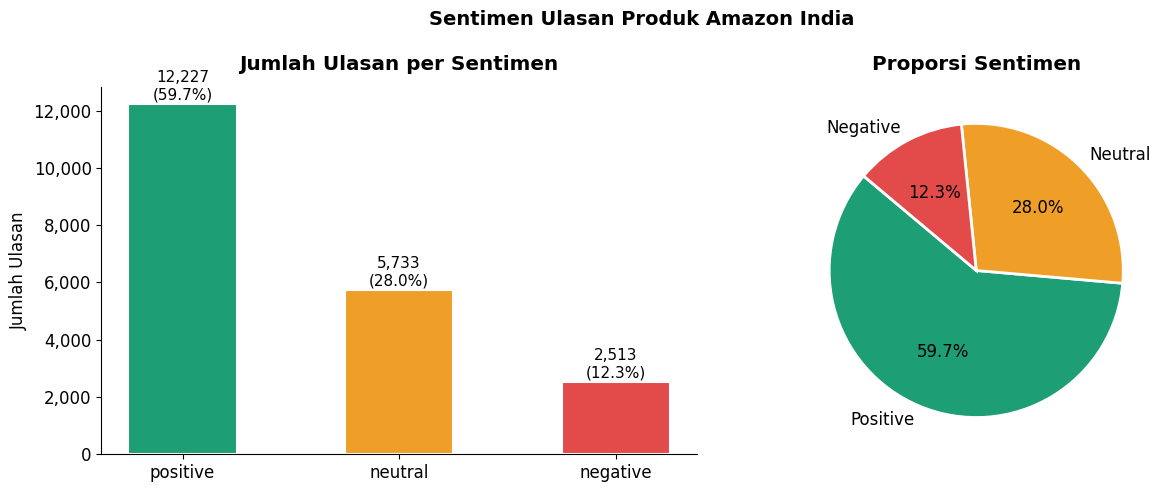

In [18]:
# visualisasi 1 — distribusi sentimen keseluruhan
urutan = ['positive', 'neutral', 'negative']
dist   = df['sentiment'].value_counts().reindex(urutan)
persen = (dist / dist.sum() * 100).round(1)
warna_list = [WARNA[s] for s in urutan]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

# bar chart
bars = ax1.bar(urutan, dist.values, color=warna_list, width=0.5,
               edgecolor='white', linewidth=1.5)
for bar, val, pct in zip(bars, dist.values, persen.values):
    ax1.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + 50,
             f'{val:,}\n({pct}%)',
             ha='center', va='bottom', fontsize=11)
ax1.set_title('Jumlah Ulasan per Sentimen', fontweight='bold', pad=12)
ax1.set_ylabel('Jumlah Ulasan')
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

# pie chart
ax2.pie(dist.values,
        labels=[s.capitalize() for s in urutan],
        colors=warna_list,
        autopct='%1.1f%%',
        startangle=140,
        wedgeprops={'edgecolor': 'white', 'linewidth': 2})
ax2.set_title('Proporsi Sentimen', fontweight='bold', pad=12)

plt.suptitle('Sentimen Ulasan Produk Amazon India', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('viz_01_distribusi_sentimen.png', dpi=150, bbox_inches='tight')
plt.show()

In [19]:
# visualisasi 2 — sentimen per kategori produk
# stacked bar horizontal supaya label kategorinya terbaca

sentimen_kat = (
    df.groupby(['main_category', 'sentiment'])
    .size()
    .reset_index(name='count')
)

total_kat = sentimen_kat.groupby('main_category')['count'].sum().reset_index(name='total')
sentimen_kat = sentimen_kat.merge(total_kat, on='main_category')
sentimen_kat['persen'] = (sentimen_kat['count'] / sentimen_kat['total'] * 100).round(1)

fig = px.bar(
    sentimen_kat,
    x='persen',
    y='main_category',
    color='sentiment',
    color_discrete_map=WARNA,
    orientation='h',
    barmode='stack',
    text='persen',
    title='Distribusi Sentimen per Kategori Produk',
    labels={
        'persen': 'Persentase (%)',
        'main_category': 'Kategori',
        'sentiment': 'Sentimen'
    }
)
fig.update_traces(texttemplate='%{text:.0f}%', textposition='inside')
fig.update_layout(height=450, plot_bgcolor='white', title_font_size=14)
fig.show()

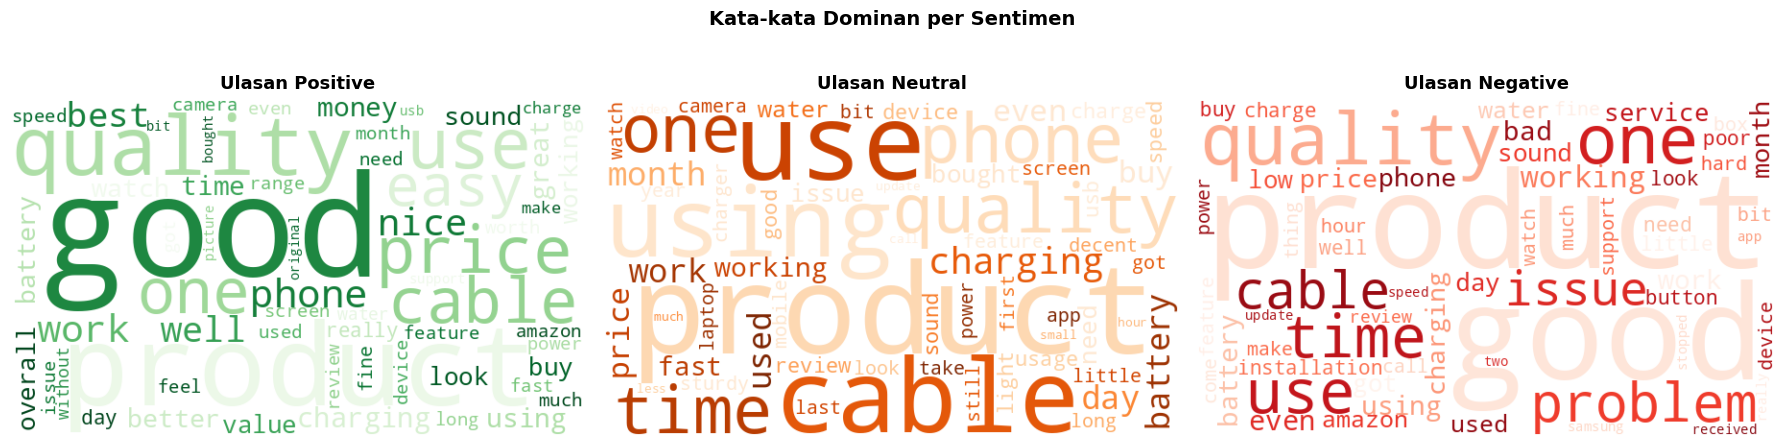

In [20]:
# visualisasi 3 — wordcloud per sentimen
# pakai review_clean supaya yang muncul kata-kata yang meaningful, bukan stopwords

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

konfigurasi = [
    ('positive', 'Greens'),
    ('neutral',  'Oranges'),
    ('negative', 'Reds')
]

for ax, (sentimen, colormap) in zip(axes, konfigurasi):
    teks_gabung = ' '.join(df[df['sentiment'] == sentimen]['review_clean'].dropna())

    if not teks_gabung.strip():
        ax.axis('off')
        continue

    wc = WordCloud(
        width=600, height=350,
        background_color='white',
        colormap=colormap,
        max_words=60,
        collocations=False
    ).generate(teks_gabung)

    ax.imshow(wc, interpolation='bilinear')
    ax.axis('off')
    ax.set_title(f'Ulasan {sentimen.capitalize()}',
                 fontweight='bold', fontsize=13, pad=8)

plt.suptitle('Kata-kata Dominan per Sentimen', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('viz_02_wordcloud.png', dpi=150, bbox_inches='tight')
plt.show()

In [21]:
# visualisasi 4 — apakah produk diskon besar lebih banyak dikeluhkan?

df['diskon_bucket'] = pd.cut(
    df['discount_percentage'],
    bins=[0, 20, 40, 60, 80, 100],
    labels=['0-20%', '21-40%', '41-60%', '61-80%', '81-100%']
)

diskon_kat = (
    df.dropna(subset=['diskon_bucket'])
    .groupby(['diskon_bucket', 'sentiment'])
    .size()
    .reset_index(name='count')
)

total_diskon = diskon_kat.groupby('diskon_bucket')['count'].sum().reset_index(name='total')
diskon_kat   = diskon_kat.merge(total_diskon, on='diskon_bucket')
diskon_kat['persen'] = (diskon_kat['count'] / diskon_kat['total'] * 100).round(1)

fig = px.bar(
    diskon_kat,
    x='diskon_bucket',
    y='persen',
    color='sentiment',
    color_discrete_map=WARNA,
    barmode='group',
    text='persen',
    title='Sentimen Ulasan Berdasarkan Tingkat Diskon',
    labels={
        'diskon_bucket': 'Rentang Diskon',
        'persen': 'Persentase (%)',
        'sentiment': 'Sentimen'
    }
)
fig.update_traces(texttemplate='%{text:.0f}%', textposition='outside')
fig.update_layout(height=430, plot_bgcolor='white', title_font_size=14)
fig.show()

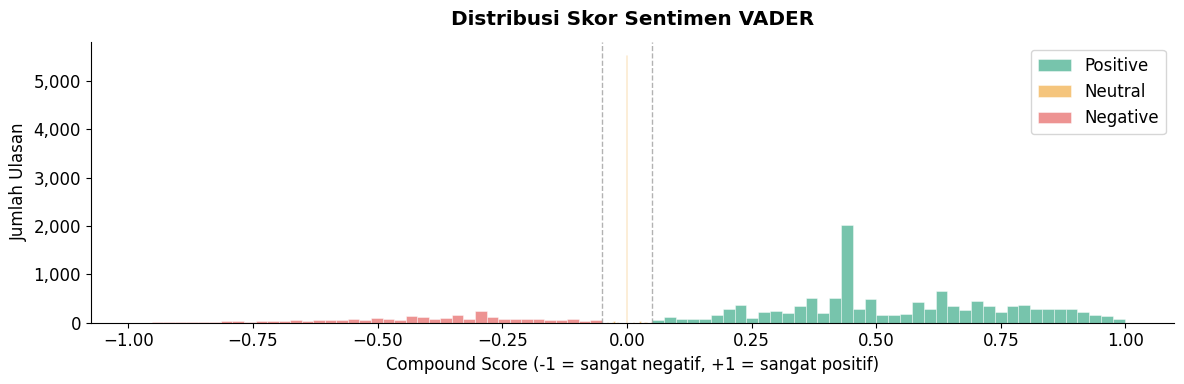

In [22]:
# visualisasi 5 — distribusi compound score VADER
# ini untuk lihat sebaran skor secara kontinu, bukan hanya 3 kategori

fig, ax = plt.subplots(figsize=(12, 4))

for sentimen, warna in WARNA.items():
    subset = df[df['sentiment'] == sentimen]['vader_compound']
    ax.hist(subset, bins=40, alpha=0.6,
            label=sentimen.capitalize(),
            color=warna, edgecolor='white', linewidth=0.5)

# garis batas pemisah antar label
ax.axvline(x= 0.05, color='gray', linestyle='--', alpha=0.6, linewidth=1)
ax.axvline(x=-0.05, color='gray', linestyle='--', alpha=0.6, linewidth=1)

ax.set_xlabel('Compound Score (-1 = sangat negatif, +1 = sangat positif)')
ax.set_ylabel('Jumlah Ulasan')
ax.set_title('Distribusi Skor Sentimen VADER', fontweight='bold', pad=12)
ax.legend()
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

plt.tight_layout()
plt.savefig('viz_03_skor_vader.png', dpi=150, bbox_inches='tight')
plt.show()

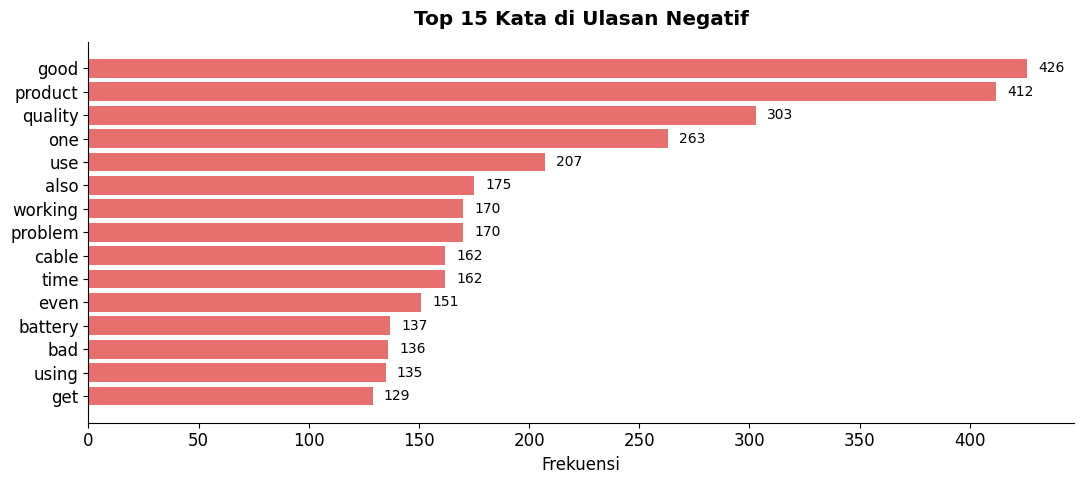

In [23]:
# visualisasi 6 — top 15 kata paling sering di ulasan negatif
# ini yang paling berguna untuk insight bisnis — apa sebenarnya yang dikeluhkan?

teks_negatif = ' '.join(df[df['sentiment'] == 'negative']['review_clean'].dropna())
top_kata = Counter(teks_negatif.split()).most_common(15)
kata_df  = pd.DataFrame(top_kata, columns=['kata', 'frekuensi'])

fig, ax = plt.subplots(figsize=(11, 5))

bars = ax.barh(
    kata_df['kata'][::-1],
    kata_df['frekuensi'][::-1],
    color='#E24B4A', alpha=0.8
)

for bar, val in zip(bars, kata_df['frekuensi'][::-1]):
    ax.text(val + 5, bar.get_y() + bar.get_height() / 2,
            f'{val:,}', va='center', fontsize=10)

ax.set_title('Top 15 Kata di Ulasan Negatif', fontweight='bold', pad=12)
ax.set_xlabel('Frekuensi')
plt.tight_layout()
plt.savefig('viz_04_kata_negatif.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Kesimpulan

Setelah menganalisis sekitar 11.700 ulasan dari produk-produk Amazon India, ini yang saya temukan:

In [24]:
# ringkasan angka kunci dari hasil analisis
total       = len(df)
pct_positif = (df['sentiment'] == 'positive').sum() / total * 100
pct_negatif = (df['sentiment'] == 'negative').sum() / total * 100

neg_per_kat = (
    df[df['sentiment'] == 'negative'].groupby('main_category').size()
    / df.groupby('main_category').size() * 100
).sort_values(ascending=False)

print(f'total ulasan dianalisis : {total:,}')
print(f'sentimen positif        : {pct_positif:.1f}%')
print(f'sentimen negatif        : {pct_negatif:.1f}%')
print()
print('kategori paling banyak keluhan:')
for kat, pct in neg_per_kat.head(3).items():
    print(f'  {kat}: {pct:.1f}% ulasan negatif')
print()
print('kategori paling sedikit keluhan:')
for kat, pct in neg_per_kat.tail(3).items():
    print(f'  {kat}: {pct:.1f}% ulasan negatif')

total ulasan dianalisis : 20,473
sentimen positif        : 59.7%
sentimen negatif        : 12.3%

kategori paling banyak keluhan:
  HomeImprovement: 15.2% ulasan negatif
  MusicalInstruments: 15.1% ulasan negatif
  Electronics: 13.4% ulasan negatif

kategori paling sedikit keluhan:
  Car&Motorbike: 9.1% ulasan negatif
  Toys&Games: 7.7% ulasan negatif
  Health&PersonalCare: 6.2% ulasan negatif


### Temuan utama

**Kepuasan pelanggan secara umum cukup baik.** Mayoritas ulasan bersentimen positif, yang konsisten dengan dominasi rating 4–5 bintang di dataset.

**Keluhan utama soal kualitas produk.** Kata-kata yang paling sering muncul di ulasan negatif seperti *quality*, *not working*, *stopped*, dan *waste* menunjukkan bahwa pelanggan paling banyak kecewa karena produk tidak awet atau tidak sesuai ekspektasi — bukan karena harga atau pengiriman.

**Diskon besar tidak selalu berarti ulasan lebih buruk.** Dari analisis bucket diskon, polanya tidak sesederhana itu. Perlu data lebih lanjut seperti data retur atau repeat purchase untuk konfirmasi.

**Rekomendasi:**
- Kategori dengan % ulasan negatif tinggi perlu fokus ke quality control, bukan promo diskon
- Ulasan yang menyebut kata *stopped working* layak ditindaklanjuti dengan kebijakan garansi yang lebih jelas
- Kategori dengan sentimen paling positif bisa jadi bahan kampanye marketing yang lebih kuat

---
*Skill yang dipakai dalam proyek ini: data cleaning, text preprocessing, sentiment analysis (VADER), dan data visualization.*

In [25]:
# simpan hasil akhir
import os
os.makedirs('output', exist_ok=True)

kolom_simpan = [
    'product_name', 'main_category', 'rating',
    'discounted_price', 'discount_percentage',
    'review_content', 'review_clean',
    'vader_compound', 'sentiment'
]

df[kolom_simpan].to_csv('output/amazon_sentiment_final.csv', index=False)

print(f'dataset tersimpan di output/amazon_sentiment_final.csv')
print(f'{len(df):,} baris ulasan dengan label sentimen')

dataset tersimpan di output/amazon_sentiment_final.csv
20,473 baris ulasan dengan label sentimen
